# MedQA Results Visualization

This notebook plots the results from Table 1 (MedQA row) showing the performance of different calibration methods.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the results
with open('../results/json/aggregated_results_medqa.json', 'r') as f:
    results = json.load(f)

In [3]:
# Define method names and labels
methods = {
    'baseline': 'Original',
    'mcal_ce': 'MCal CE',
    'mcal_ce_uncond': 'MCal CE Uncond'
}

# Extract data for each method
data = {}
for key, label in methods.items():
    if key == 'baseline':
        data[label] = results[key]['fraction_wise_results']['mean_argmax']
    else:
        data[label] = results[key]['fraction_wise_results_transformed']['mean_argmax']

# Create x-axis (fraction values)
n_points = len(next(iter(data.values())))
fractions = np.linspace(0, 1, n_points)

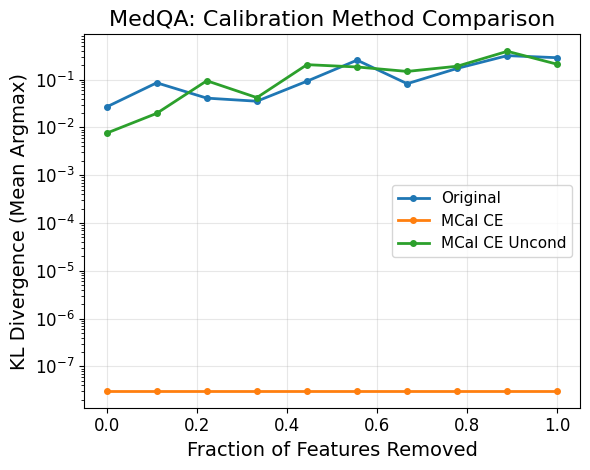

In [4]:
# Create the plot with log scale
plt.figure(figsize=(6, 4.8))

# Plot each method
for label, values in data.items():
    plt.plot(fractions, values, marker='o', label=label, linewidth=2, markersize=4)

plt.xlabel('Fraction of Features Removed', fontsize=14)
plt.ylabel('KL Divergence (Mean Argmax)', fontsize=14)
plt.title('MedQA: Calibration Method Comparison', fontsize=16)
plt.yscale('log')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

In [5]:
# Display summary statistics
print("Summary Statistics (Mean KL Divergence across all fractions):")
print("="*60)
for label, values in data.items():
    mean_kl = np.mean(values)
    print(f"{label:15s}: {mean_kl:.6f}")

Summary Statistics (Mean KL Divergence across all fractions):
Original       : 0.139459
MCal CE        : 0.000000
MCal CE Uncond : 0.149139
